In [1]:
import matplotlib.pyplot as plt


In [2]:
# Robust loader handling both old "batch" and "flattened" merged formats

import glob
import pickle
import pandas as pd

files = sorted(glob.glob("data_batches/merged_*.pkl")) # + glob.glob("data_batches/batch_*.pkl")

rows = []
for fp in files:
    with open(fp, "rb") as f:
        data = pickle.load(f)
    
    # Data may be:
    # 1) A dict with "params" (N×7 array) and "results" (list of dicts)
    # 2) A list whose elements are either:
    #    a) batch-dicts with "params"/"results" (old-merged)
    #    b) single-point dicts with "params" (length-7 array) and "result"/"results" (dict)
    
    # Helper to flatten a batch-dict
    def flatten_batch(batch):
        ps = batch["params"]
        rs = batch["results"]
        for p, r in zip(ps, rs):
            yield p, r
    
    # Helper to flatten a single-point dict
    def flatten_point(entry):
        p = entry["params"]
        # entry may use "result" or "results"
        r = entry.get("result", entry.get("results"))
        if isinstance(r, list):  # sometimes "results" is a list of 1 dict
            r = r[0]
        yield p, r
    
    # Now dispatch
    if isinstance(data, dict) and "params" in data and "results" in data:
        # Single batch file
        for p, r in flatten_batch(data):
            row = {
                "m_phi":      p[0],
                "m_A":    p[1],
                "sin_ba":   p[2],
                "tan_beta": p[3],
                "lambda_6": p[4],
                "lambda_7": p[5],
                "m12_2":    p[6],
                **r
            }
            rows.append(row)
    
    elif isinstance(data, list):
        # Merged file: list of entries
        for entry in data:
            if isinstance(entry, dict):
                if "params" in entry and "results" in entry:
                    # This entry is a full batch
                    for p, r in flatten_batch(entry):
                        row = {
                            "m_phi":      p[0],
                            "m_A":    p[1],
                            "sin_ba":   p[2],
                            "tan_beta": p[3],
                            "lambda_6": p[4],
                            "lambda_7": p[5],
                            "m12_2":    p[6],
                            **r
                        }
                        rows.append(row)
                elif "params" in entry:
                    # Single-point entry
                    for p, r in flatten_point(entry):
                        row = {
                            "m_phi":      p[0],
                            "m_A":    p[1],
                            "sin_ba":   p[2],
                            "tan_beta": p[3],
                            "lambda_6": p[4],
                            "lambda_7": p[5],
                            "m12_2":    p[6],
                            **r
                        }
                        rows.append(row)
                else:
                    raise ValueError(f"Unexpected dict keys in entry from {fp}: {entry.keys()}")
            else:
                raise ValueError(f"Unexpected entry type in merged list from {fp}: {type(entry)}")
    else:
        raise ValueError(f"Unknown data structure in file {fp}: {type(data)}")

# 3) Build DataFrame and save to Parquet (or fallback to CSV)
df = pd.DataFrame(rows)

# try:
#     df.to_parquet("data_train/dataset_full.parquet", index=False)
#     print(f"Saved merged dataset with {len(df)} rows to dataset_full.parquet")
# except Exception as e:
#     print("Failed to write Parquet:", e)
#     df.to_csv("data_train/dataset_full.csv", index=False)
#     print("Saved merged dataset to dataset_full.csv")


## Tipos de errores
El analisis puede entregar: `{'Execution failed', 'Invalid parameter set.', nan}`
Es necesario conocer la distribucion de parametros que da lugar a esto, entender si el fallo es por algun parametro o un error computacional aleatorio

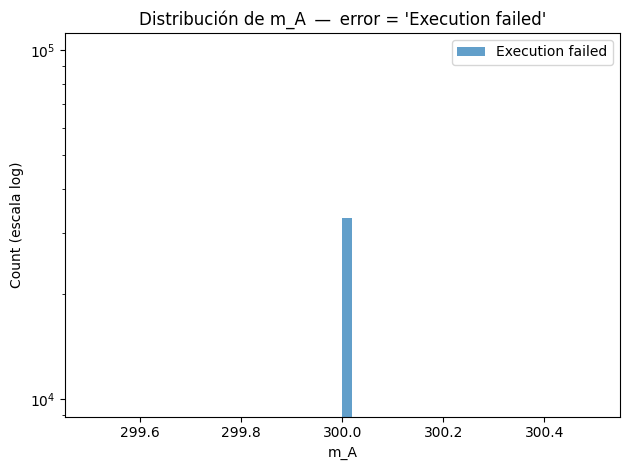

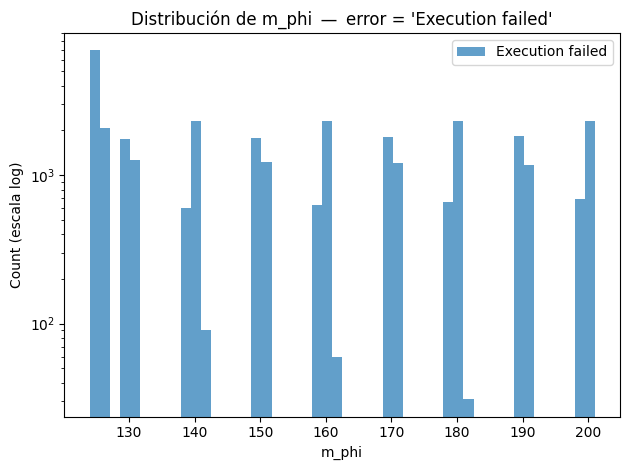

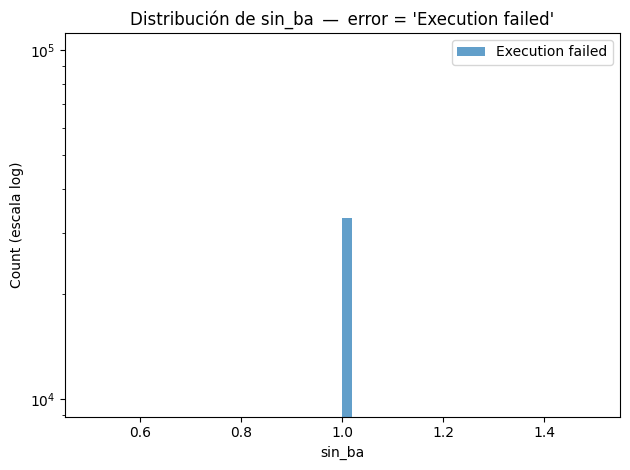

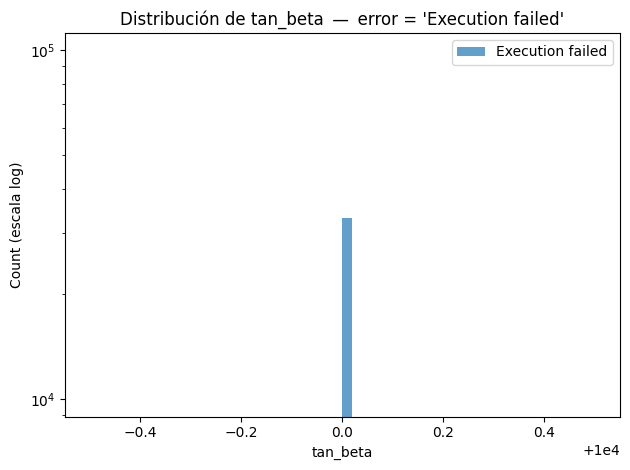

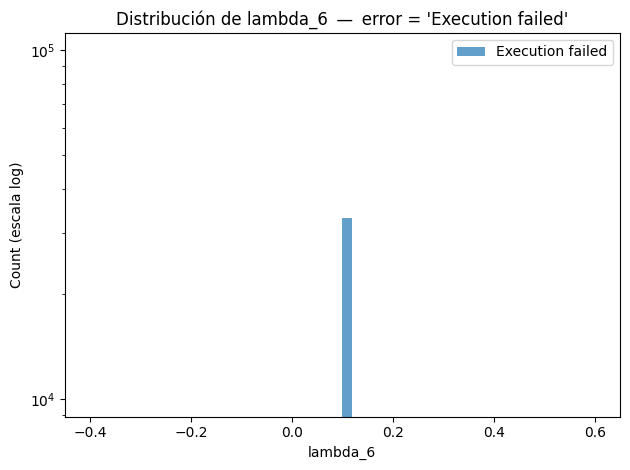

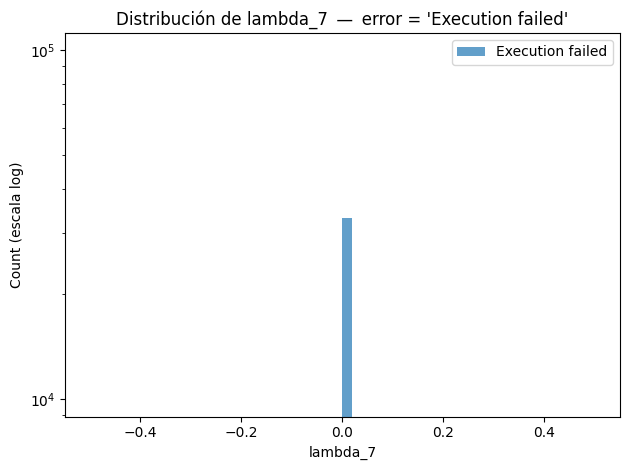

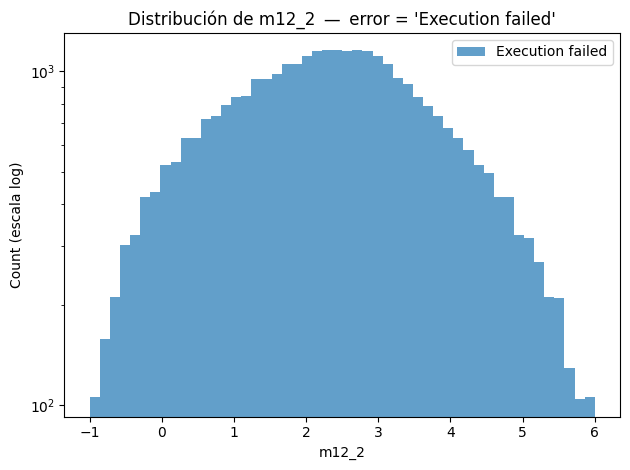

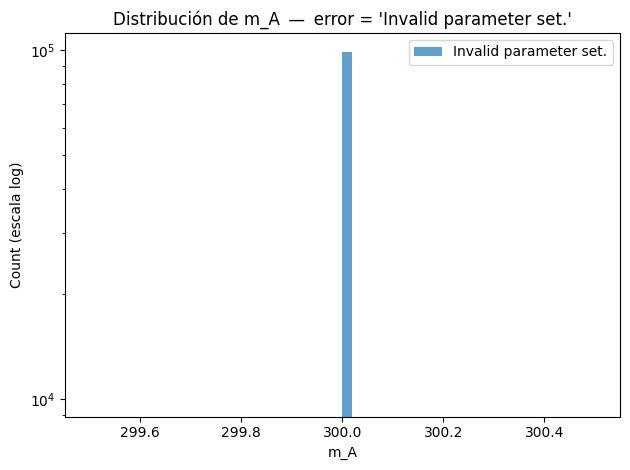

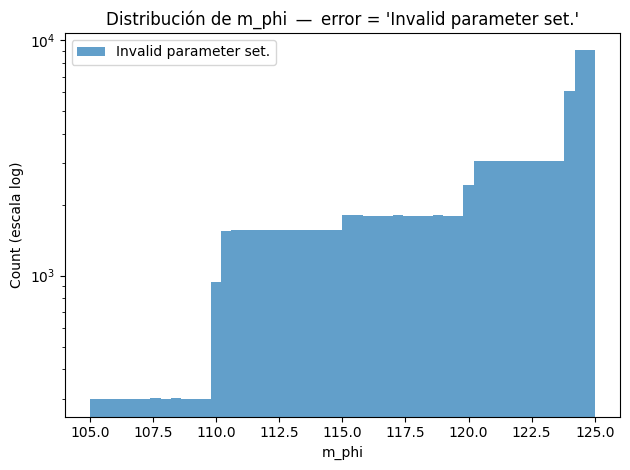

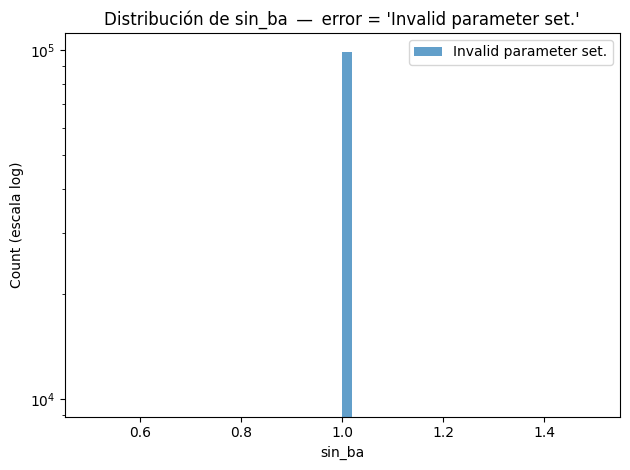

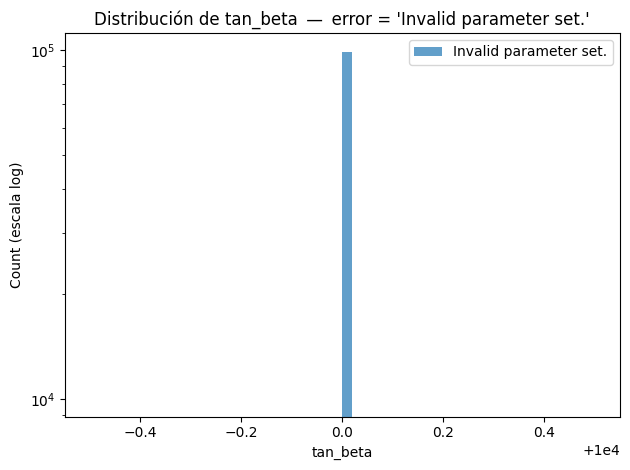

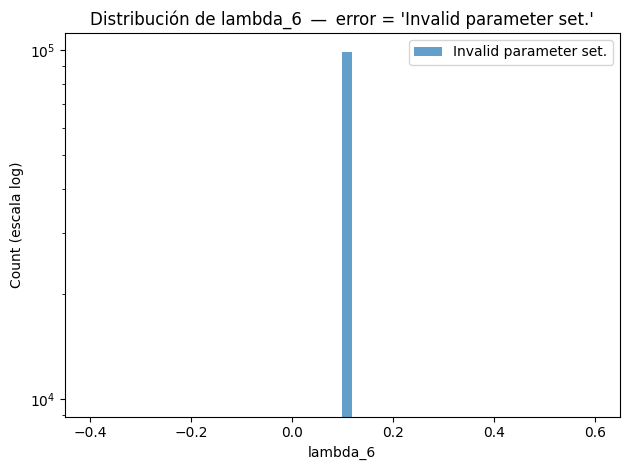

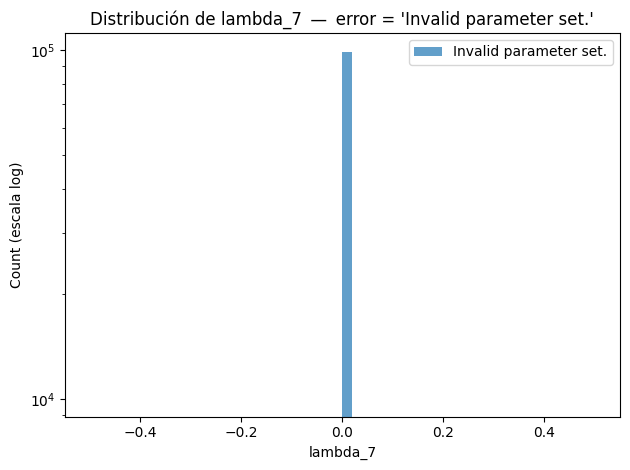

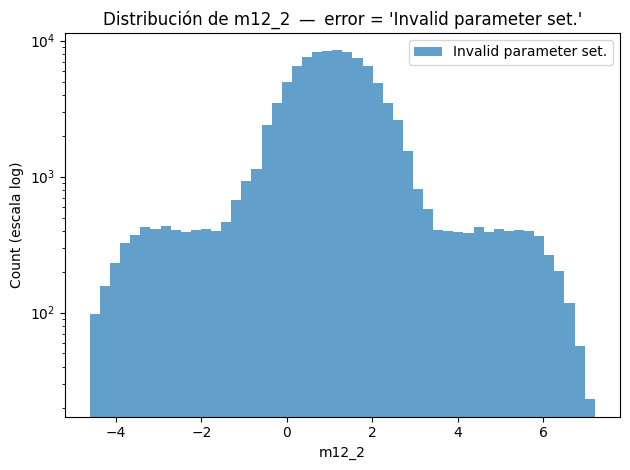

In [3]:
idx_exec_fail   = df.index[df['error'] == "Execution failed"]
idx_invalid_set = df.index[df['error'] == "Invalid parameter set."]

df_exec_fail   = df.loc[idx_exec_fail]
df_invalid_set = df.loc[idx_invalid_set]

# funcion plotting
def plot_param_distributions(df_filtered, param_cols, label_error):
    for col in param_cols:
        datos = df_filtered[col].dropna()
        if datos.empty:
            continue
        plt.figure()
        plt.hist(datos, bins=50, alpha=0.7, label=f"{label_error}", log=True)
        plt.xlabel(col)
        plt.ylabel("Count (escala log)")
        plt.title(f"Distribución de {col}  —  error = '{label_error}'")
        plt.legend()
        plt.tight_layout()
        plt.show()


param_cols = ['m_A', 'm_phi', 'sin_ba', 'tan_beta', 'lambda_6', 'lambda_7', 'm12_2']
plot_param_distributions(df_exec_fail,   param_cols, "Execution failed")
plot_param_distributions(df_invalid_set, param_cols, "Invalid parameter set.")


In [4]:
# que tienen en comun? m-phi = 300
print(df_exec_fail.head())

print(df_invalid_set.head())

             m_phi    m_A  sin_ba  tan_beta  lambda_6  lambda_7     m12_2  \
822000  124.527423  300.0     1.0   10000.0       0.1       0.0  1.291644   
822001  125.827001  300.0     1.0   10000.0       0.1       0.0  1.867023   
822002  124.515205  300.0     1.0   10000.0       0.1       0.0  1.141696   
822003  124.732266  300.0     1.0   10000.0       0.1       0.0  0.459011   
822004  125.986633  300.0     1.0   10000.0       0.1       0.0  1.955768   

        positivity_ok  unitarity_ok  perturbativity_ok  ...  w_total_top  \
822000            NaN           NaN                NaN  ...          NaN   
822001            NaN           NaN                NaN  ...          NaN   
822002            NaN           NaN                NaN  ...          NaN   
822003            NaN           NaN                NaN  ...          NaN   
822004            NaN           NaN                NaN  ...          NaN   

        branching_ratio_h2_gaga  lambda1  lambda2  lambda3 lambda4  lambda5  \
8

Limpieza de datos, procedemos a quitar los puntos problematicos

In [5]:
# 1) Definir los valores de error a eliminar
errores_prohibidos = ["Execution failed", "Invalid parameter set."]

# 2) Filtrar el DataFrame para quedarnos sólo con filas que NO tengan esos errores
df_filtrado = df[~df["error"].isin(errores_prohibidos)].copy()

# 3) Eliminar la columna 'error'
df = df_filtrado.drop(columns=["error"])
del(df_filtrado)
# Ahora df_filtrado no contiene ninguna fila con esos errors y ya no tiene la columna 'error'.


In [6]:
df.dropna(inplace=True)

In [7]:
df.columns

Index(['m_phi', 'm_A', 'sin_ba', 'tan_beta', 'lambda_6', 'lambda_7', 'm12_2',
       'positivity_ok', 'unitarity_ok', 'perturbativity_ok', 'w_h2_bb',
       'w_h2_tautau', 'w_h2_uu', 'w_h2_du', 'w_h2_ln', 'w_h2_vv', 'w_h2_gaga',
       'w_h2_Zga', 'w_h2_gg', 'w_h2_hh', 'w_total_h2', 'w_total_top',
       'branching_ratio_h2_gaga', 'lambda1', 'lambda2', 'lambda3', 'lambda4',
       'lambda5', 'lambda6', 'lambda7'],
      dtype='object')

In [8]:
df.head()

,m_phi,m_A,sin_ba,tan_beta,lambda_6,lambda_7,m12_2,positivity_ok,unitarity_ok,perturbativity_ok,...,w_total_h2,w_total_top,branching_ratio_h2_gaga,lambda1,lambda2,lambda3,lambda4,lambda5,lambda6,lambda7
0,150.000001,299.932979,1.0,10000.0,0.1,0.0,2.249909,1.0,1.0,1.0,...,6.234823e-11,1.338069,0.810530,1.129741,0.257734,2.483237,-1.112767,-1.112767,0.1,0.0
1,150.000001,300.088086,1.0,10000.0,0.1,0.0,2.249909,1.0,1.0,1.0,...,6.219700e-11,1.338069,0.810532,0.986840,0.257734,2.486308,-1.114302,-1.114302,0.1,0.0
2,150.000001,299.964114,1.0,10000.0,0.1,0.0,2.249909,1.0,1.0,1.0,...,6.229792e-11,1.338069,0.810530,0.941077,0.257734,2.483853,-1.113075,-1.113075,0.1,0.0
3,150.000001,299.970720,1.0,10000.0,0.1,0.0,2.249909,1.0,1.0,1.0,...,6.232818e-11,1.338069,0.810530,1.229779,0.257734,2.483984,-1.113140,-1.113140,0.1,0.0
4,150.000001,299.984367,1.0,10000.0,0.1,0.0,2.249909,1.0,1.0,1.0,...,6.231107e-11,1.338069,0.810531,1.186756,0.257734,2.484254,-1.113275,-1.113275,0.1,0.0


# Data exploration

Columna nueva agrada para estudiar la perturbatividad

In [9]:
# df[df["m12_2"] < 100]
cols = [f'lambda{i}' for i in range(1, 8)]
df['sq_lambda'] = df[cols].pow(2).sum(axis=1)

# 4) Comprobación rápida
print(df[['sq_lambda']].head())

   sq_lambda
0   9.995709
1   9.715343
2   9.609451
3  10.237122
4  10.135099


In [10]:
(df['m_A'] == 300.0).sum()

729000

Calculando la distribucion de las clases

In [11]:
# basics 
print(
    sum(df["positivity_ok"]),
    sum(df["perturbativity_ok"]),
    sum(df["unitarity_ok"]) )

626426.0 145833.0 151295.0


In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# — asume que df ya está cargado —

# 1) Class counts
print("Class counts:")
print(df[["positivity_ok", "perturbativity_ok", "unitarity_ok"]].sum())
print()

# 2) Descriptive statistics para cada “OK” class
for col in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    print(f"=== Descriptive stats for {col} == 1 ===")
    print(df[df[col] == 1].describe().T)
    print()

# 3) Rango de parámetros donde cada clase == 1
params = ["m_A","m_phi","m12_2","tan_beta","sin_ba","lambda_6","lambda_7"]
for col in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    subset = df[df[col] == 1][params]
    mins = subset.min()
    maxs = subset.max()
    ranges = pd.concat([mins, maxs], axis=1)
    ranges.columns = ["min", "max"]
    print(f"=== Ranges for {col} == 1 ===")
    print(ranges)
    print()

# ─────────────────────────────────────────────────────────────────────
# 6) Histograms por clase para cada parámetro, pero guardando imágenes
# ─────────────────────────────────────────────────────────────────────

# 6.1 Definimos el mapeo entre la columna “tipo” y la etiqueta “filtro”:
mapeo_filtro = {
    "positivity_ok":    "positivity",
    "perturbativity_ok": "perturb",
    "unitarity_ok":      "unitary"
}

# 6.2 Definimos la carpeta donde se guardarán las imágenes:
output_dir = "/home/ftrigo/Dihiggs/mlpython/img"

# Si la carpeta no existe, la creamos
os.makedirs(output_dir, exist_ok=True)

# 6.3 Recorremos cada “tipo” (filtro) y cada parámetro, generando y guardando el histograma
for tipo in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    filtro = mapeo_filtro[tipo]  # p.ej. "positivity", "perturb" o "unitary"
    
    for col in params:
        plt.figure(figsize=(6, 4))
        
        # Graficar ambos valores de la clase: cls_val = 0 ó 1
        for cls_val in [0, 1]:
            subset = df[df[tipo] == cls_val]
            if subset[col].isna().all():
                # Si todos son NaN, saltamos
                continue
            
            plt.hist(
                subset[col].dropna(),
                bins=50,
                alpha=0.5,
                label=f"{tipo}={cls_val}"
            )
        
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.yscale("log")
        plt.title(f"Distribución de {col} por {tipo}")
        plt.legend()
        plt.tight_layout()
        
        # Construir el nombre del archivo
        # Formato: v0602-(filtro)_(nombre_variable).png
        filename = f"v0602-{filtro}_{col}.png"
        fullpath = os.path.join(output_dir, filename)
        
        # Guardar la figura
        plt.savefig(fullpath, dpi=150)
        plt.close()  # Cerramos la figura para liberar memoria
        
        print(f"> Guardado: {fullpath}")

# Al finalizar tendrás en /home/ftrigo/Dihiggs/mlpython/img/:
#   v0602-positivity_m_A.png
#   v0602-positivity_m_phi.png
#   ...
#   v0602-positivity_lambda_7.png
#   v0602-positivity_m12_2.png
#   v0602-perturb_m_A.png
#   ...
#   v0602-unitary_lambda_7.png
#   v0602-unitary_m12_2.png


Class counts:
positivity_ok        626426.0
perturbativity_ok    145833.0
unitarity_ok         151295.0
dtype: float64

=== Descriptive stats for positivity_ok == 1 ===
                            count          mean           std           min  \
m_phi                    626426.0  1.938640e+02  5.708179e+01  1.250000e+02   
m_A                      626426.0  3.000000e+02  1.451758e-02  2.999000e+02   
sin_ba                   626426.0  1.000000e+00  0.000000e+00  1.000000e+00   
tan_beta                 626426.0  1.000000e+04  0.000000e+00  1.000000e+04   
lambda_6                 626426.0  1.000000e-01  1.387780e-16  1.000000e-01   
lambda_7                 626426.0  0.000000e+00  0.000000e+00  0.000000e+00   
m12_2                    626426.0  3.366870e+00  2.507532e+00 -4.609616e+00   
positivity_ok            626426.0  1.000000e+00  0.000000e+00  1.000000e+00   
unitarity_ok             626426.0  1.847688e-01  3.881102e-01  0.000000e+00   
perturbativity_ok        626426.0  1.8041

Class counts:
positivity_ok        626426.0
perturbativity_ok    145833.0
unitarity_ok         151295.0
dtype: float64

=== Descriptive stats for positivity_ok == 1 ===
                            count          mean           std           min  \
m_phi                    626426.0  1.938640e+02  5.708179e+01  1.250000e+02   
m_A                      626426.0  3.000000e+02  1.451758e-02  2.999000e+02   
sin_ba                   626426.0  1.000000e+00  0.000000e+00  1.000000e+00   
tan_beta                 626426.0  1.000000e+04  0.000000e+00  1.000000e+04   
lambda_6                 626426.0  1.000000e-01  1.387780e-16  1.000000e-01   
lambda_7                 626426.0  0.000000e+00  0.000000e+00  0.000000e+00   
m12_2                    626426.0  3.366870e+00  2.507532e+00 -4.609616e+00   
positivity_ok            626426.0  1.000000e+00  0.000000e+00  1.000000e+00   
unitarity_ok             626426.0  1.847688e-01  3.881102e-01  0.000000e+00   
perturbativity_ok        626426.0  1.8041

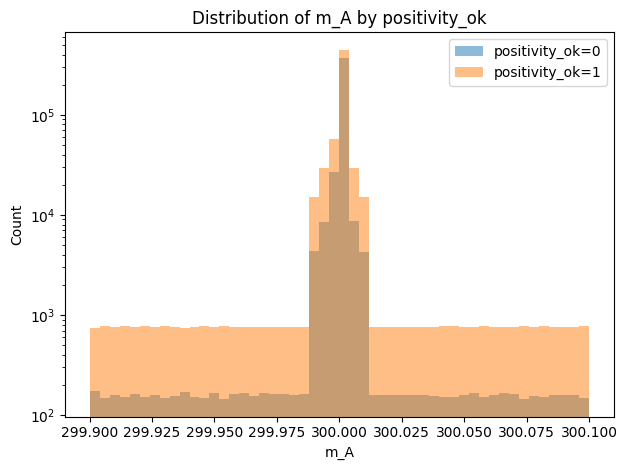

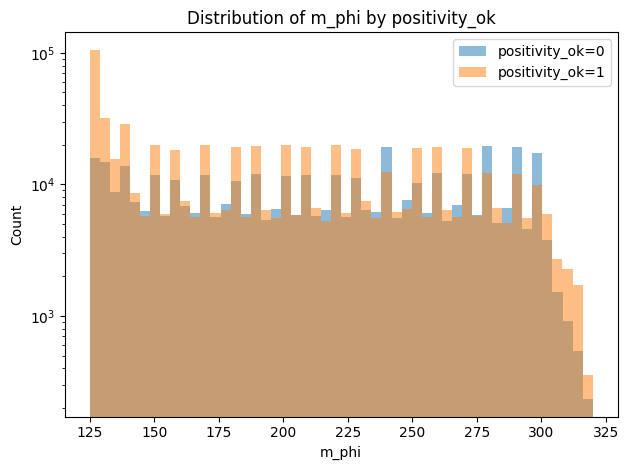

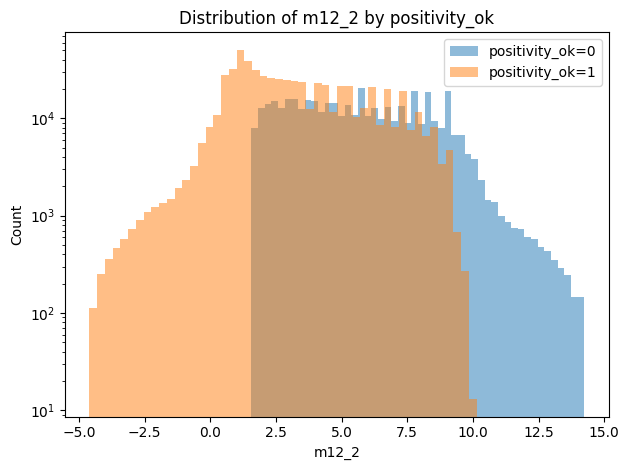

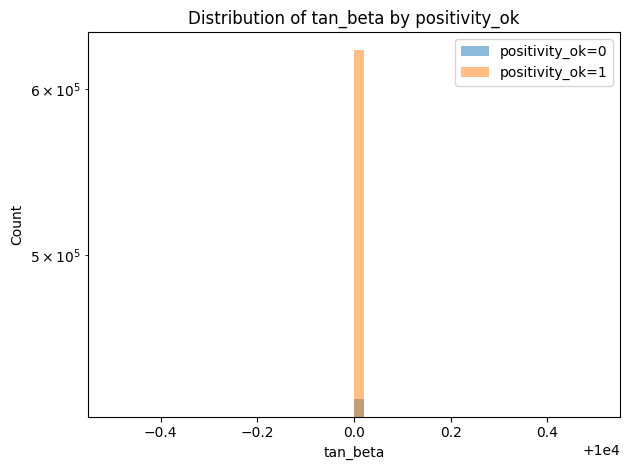

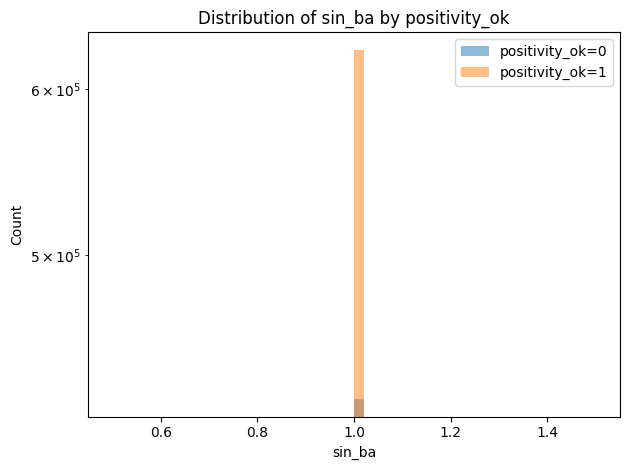

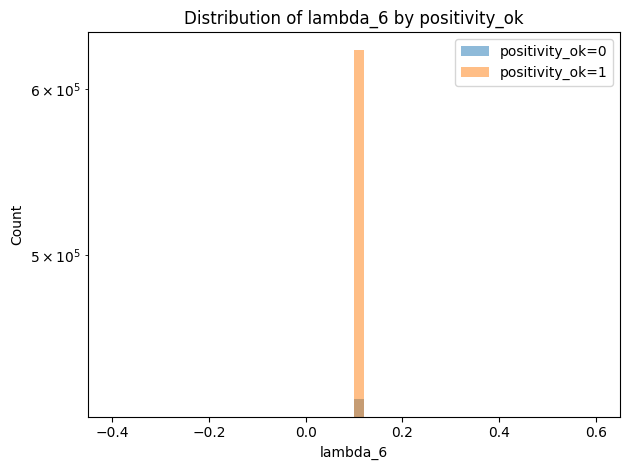

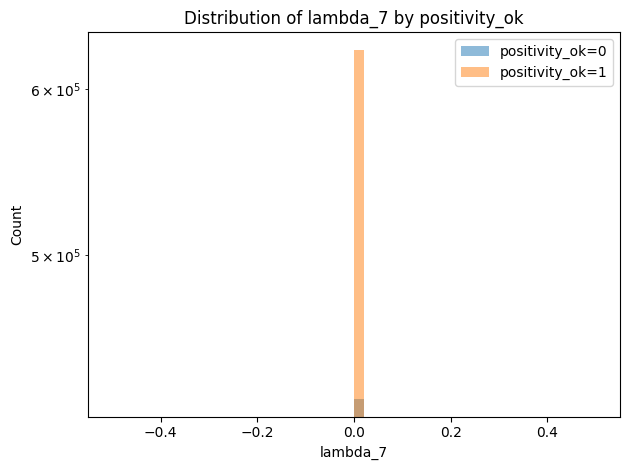

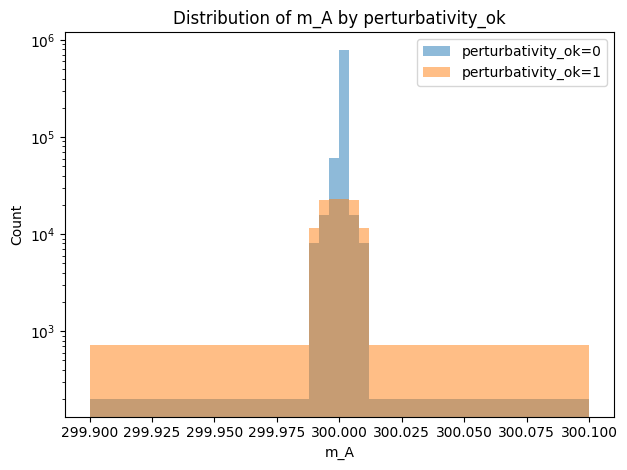

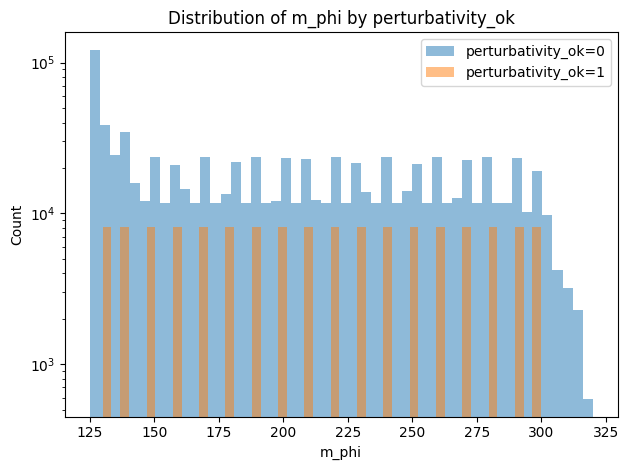

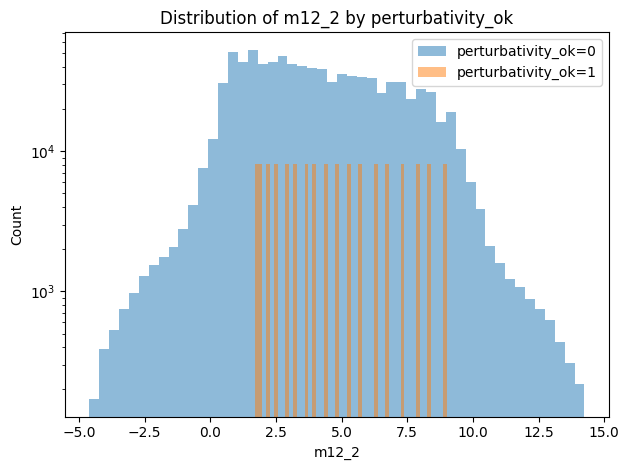

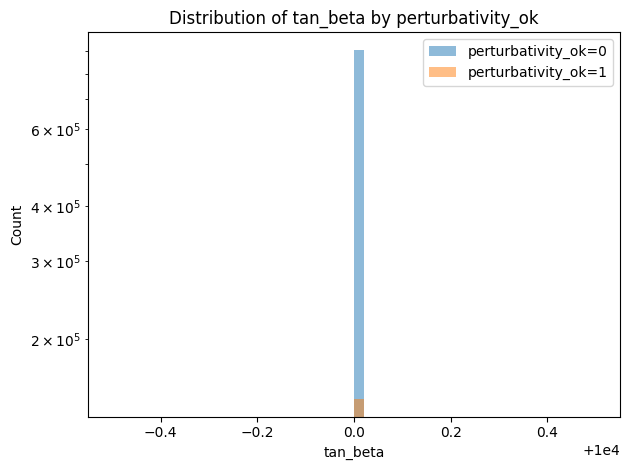

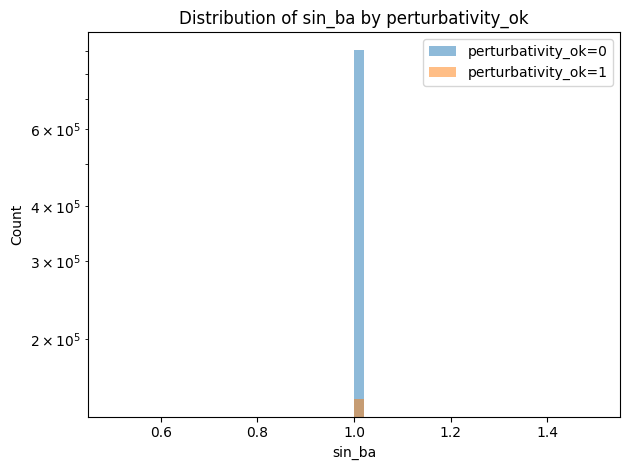

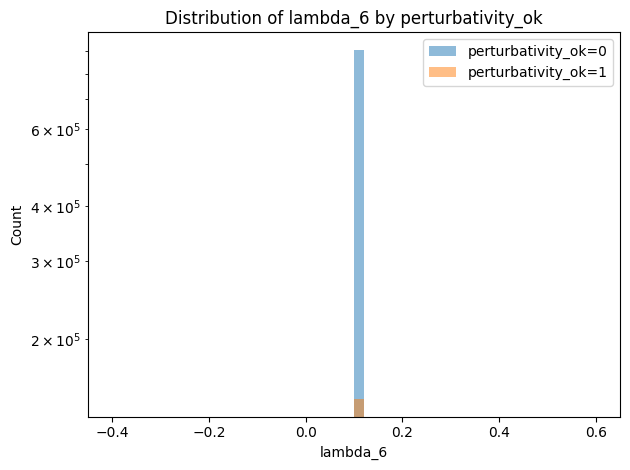

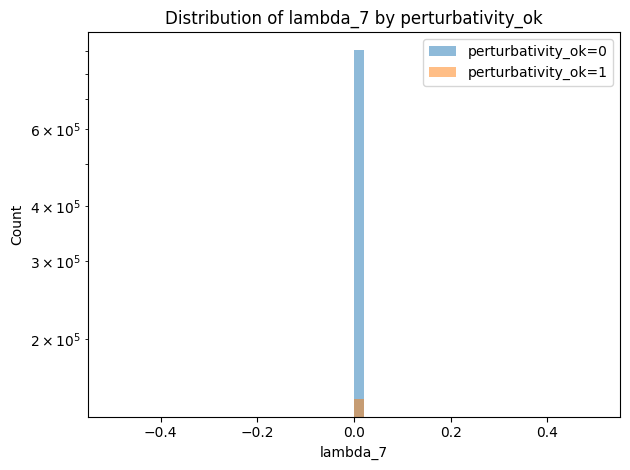

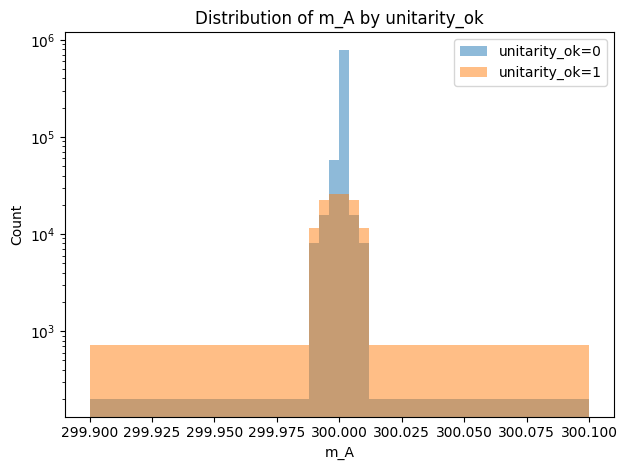

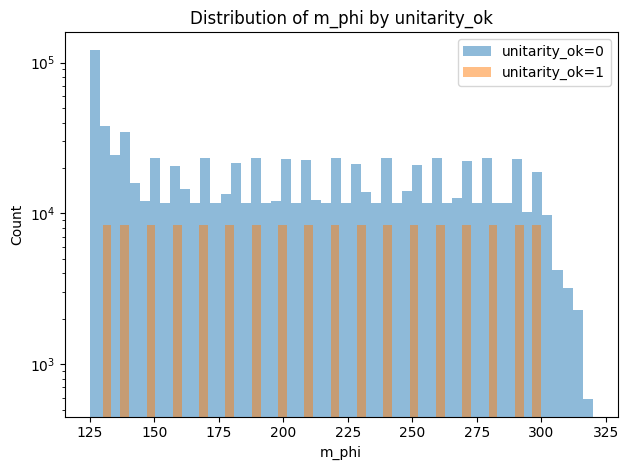

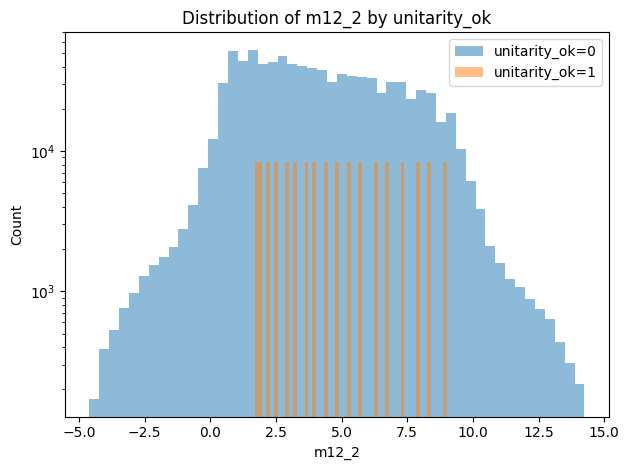

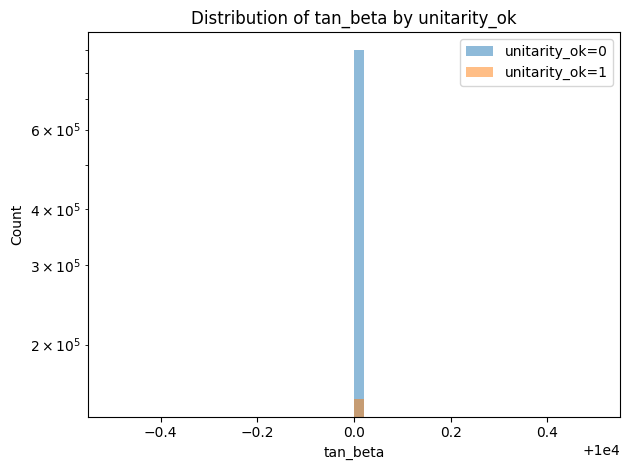

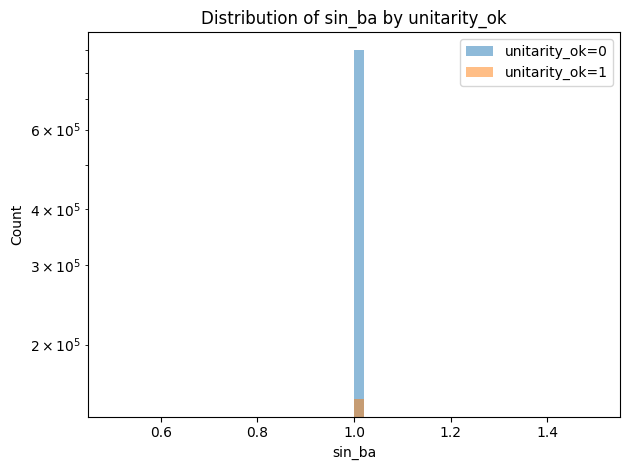

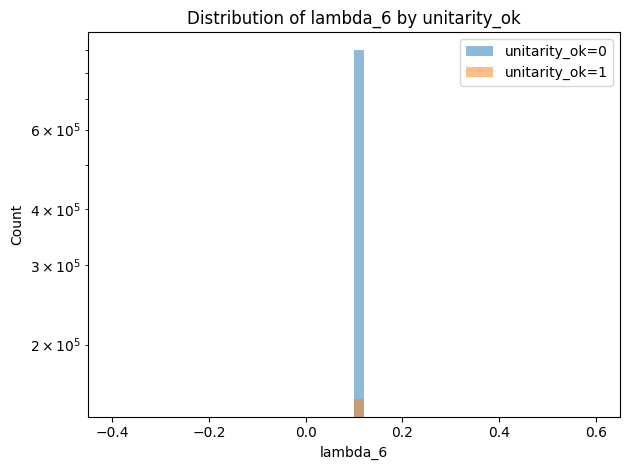

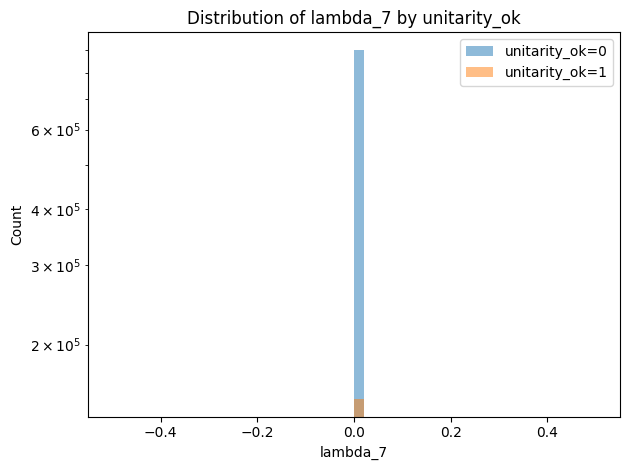

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# — assume df is already loaded —

# 1) Class counts
print("Class counts:")
print(df[["positivity_ok", "perturbativity_ok", "unitarity_ok"]].sum())
print()

# 2) Descriptive statistics for each “OK” class
for col in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    print(f"=== Descriptive stats for {col} == 1 ===")
    print(df[df[col] == 1].describe().T)
    print()

# 3) Parameter ranges where each class==1
params = ["m_A","m_phi","m12_2","tan_beta","sin_ba","lambda_6","lambda_7"]
for col in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    subset = df[df[col] == 1][params]
    mins = subset.min()
    maxs = subset.max()
    ranges = pd.concat([mins, maxs], axis=1)
    ranges.columns = ["min", "max"]
    print(f"=== Ranges for {col} == 1 ===")
    print(ranges)
    print()


# 6) Histograms by class for each parameter
for tipo in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    for col in params:
        plt.figure()
        for cls_val in [0, 1]:
            subset = df[df[tipo] == cls_val]
            counts, bins, _ = plt.hist(subset[col], bins=50, alpha=0.5,
                    label=f"{tipo}={cls_val}")
            
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.yscale("log")
        plt.title(f"Distribution of {col} by {tipo}")
        plt.legend()
        plt.tight_layout()
        plt.show()




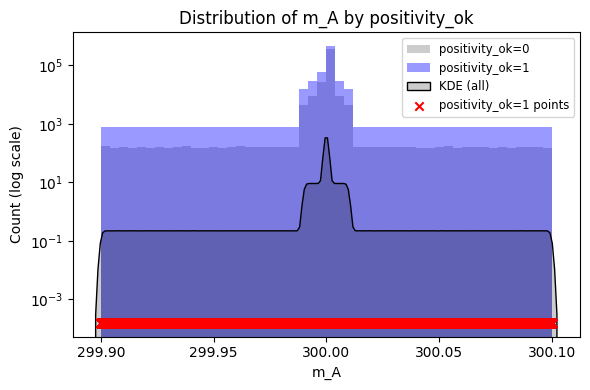

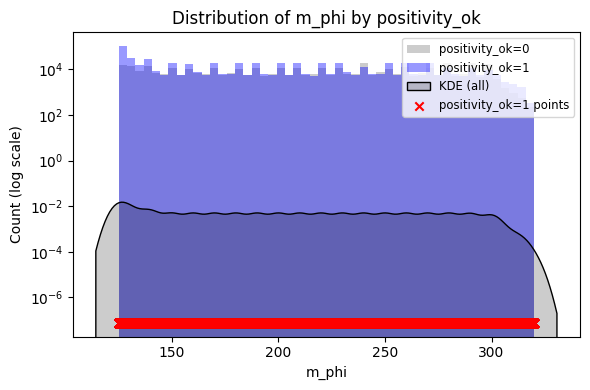

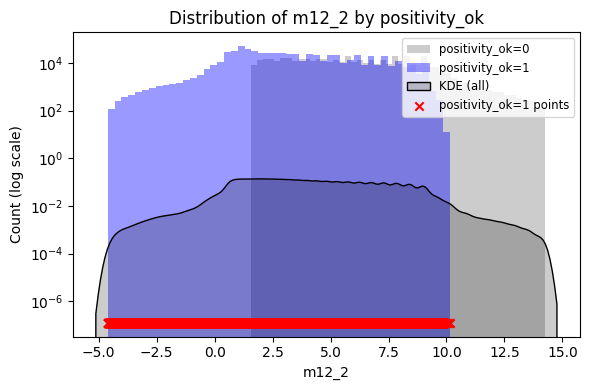

/tmp/ipykernel_5129/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


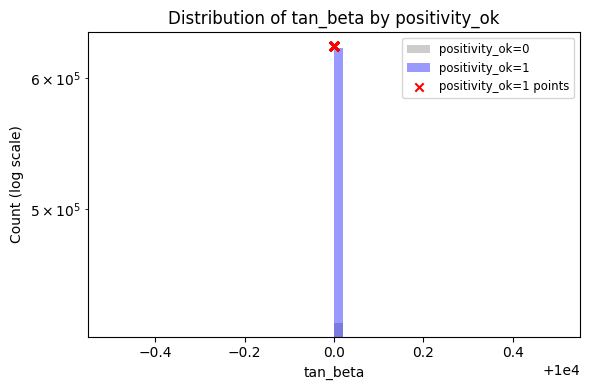

/tmp/ipykernel_5129/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


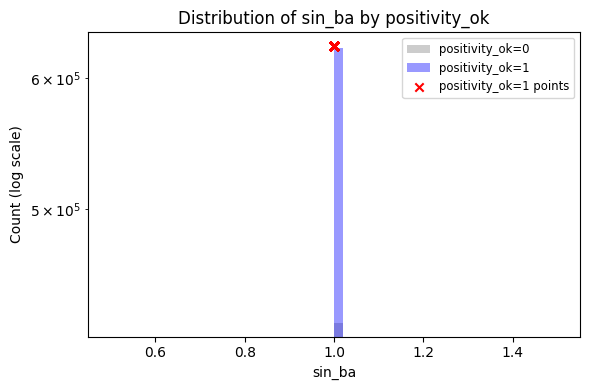

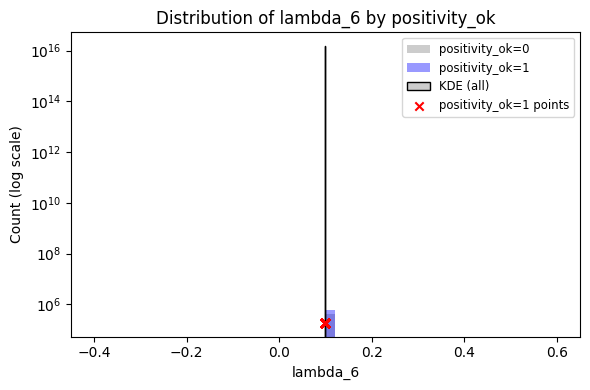

/tmp/ipykernel_5129/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


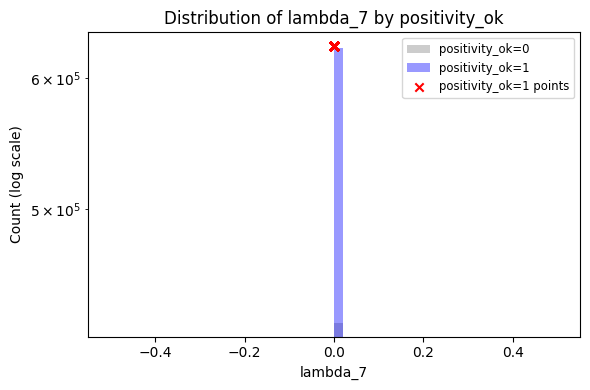

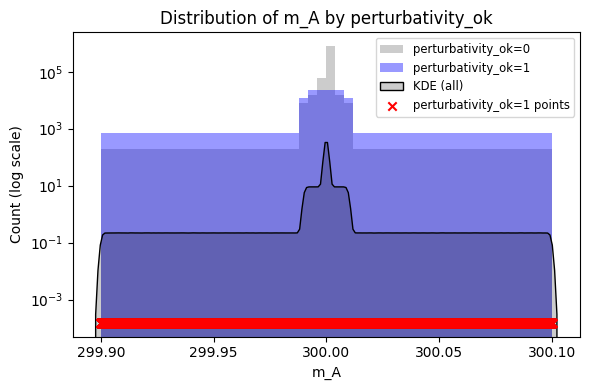

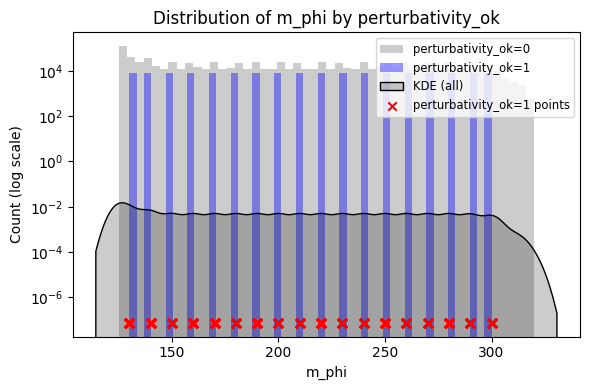

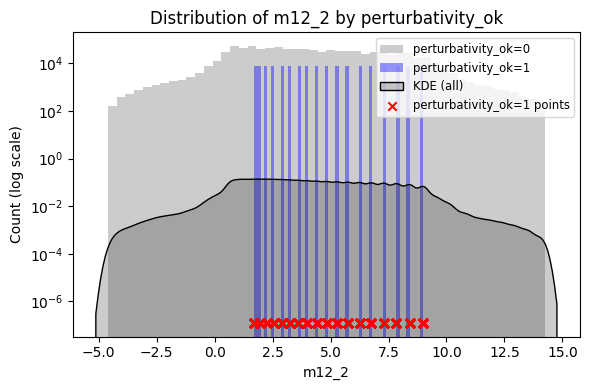

/tmp/ipykernel_5129/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


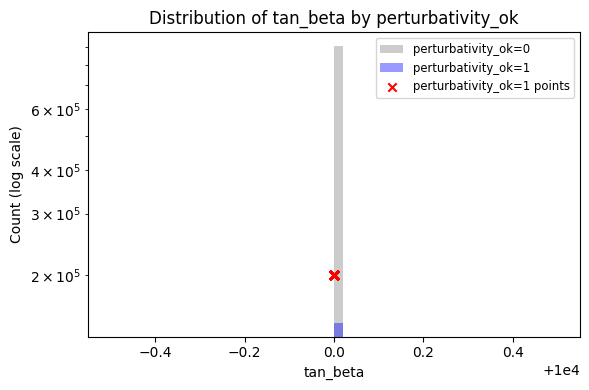

/tmp/ipykernel_5129/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


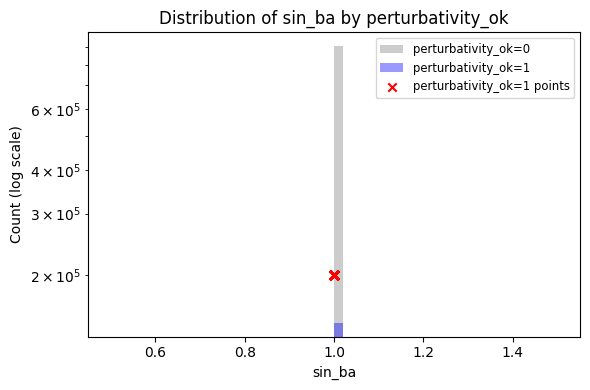

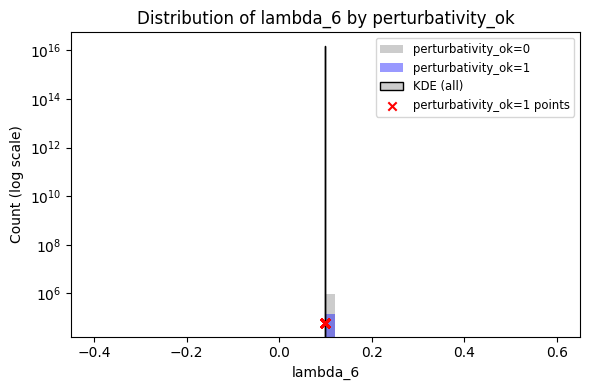

/tmp/ipykernel_5129/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


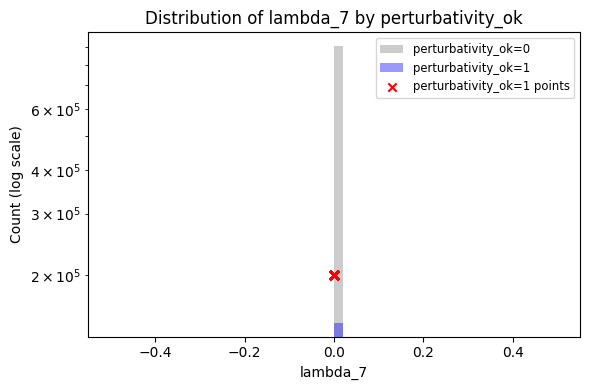

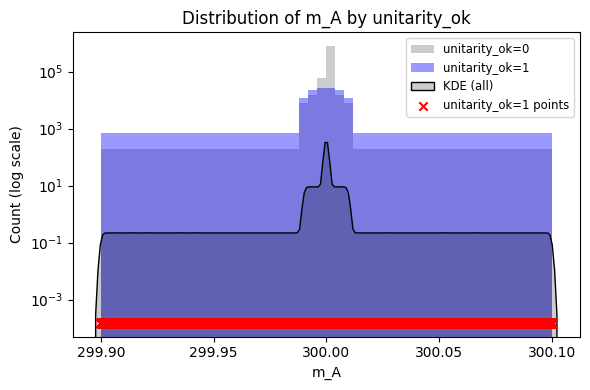

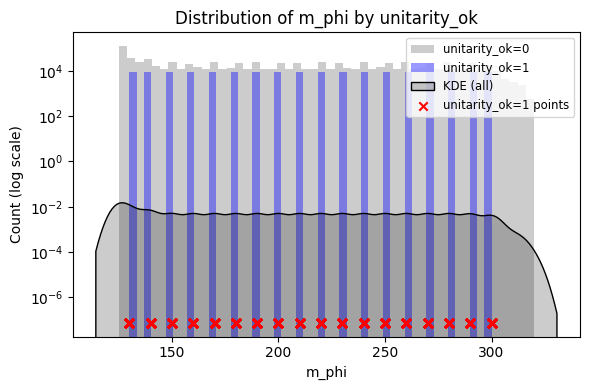

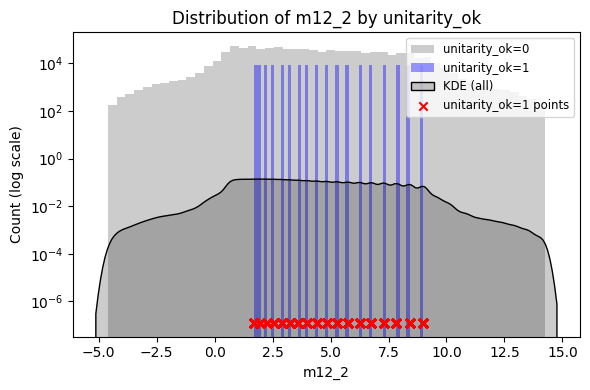

/tmp/ipykernel_5129/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


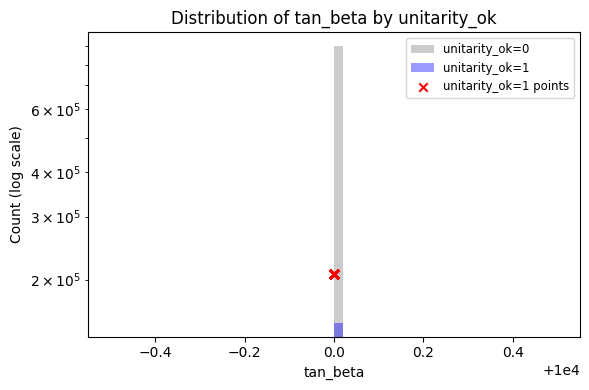

/tmp/ipykernel_5129/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


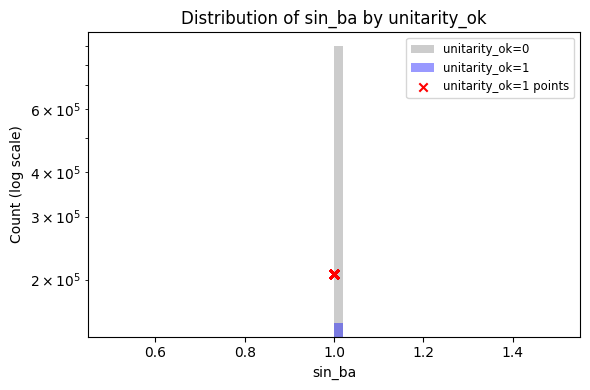

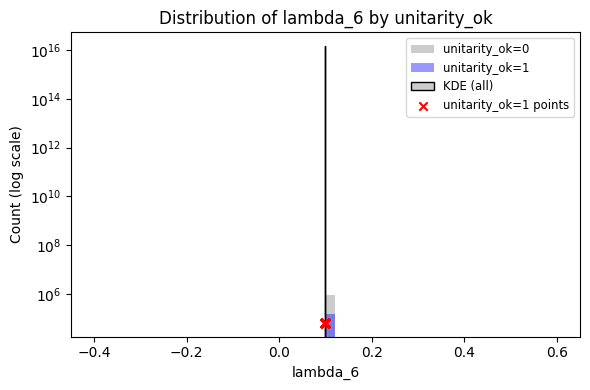

/tmp/ipykernel_5129/3396619420.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")


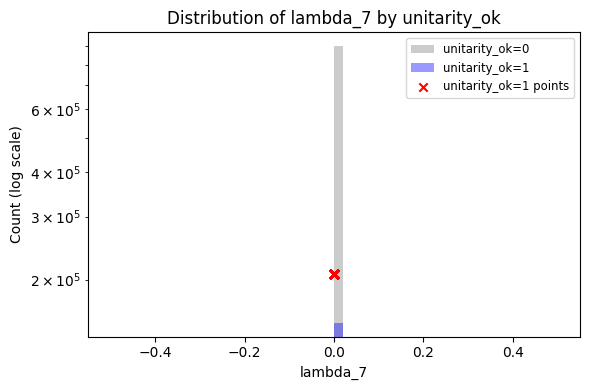

In [13]:
import seaborn as sns

# 6) Histograms + KDE + rare-point markers by class for each parameter
for tipo in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    for col in params:
        plt.figure(figsize=(6,4))
        
        # Plot histogram (log scale) for both classes
        for cls_val, color in zip([0,1], ["gray", "blue"]):
            subset = df[df[tipo] == cls_val]
            plt.hist(subset[col], bins=50, alpha=0.4, density=False, 
                     color=color, label=f"{tipo}={cls_val}")
        
        plt.yscale("log")
        plt.xlabel(col)
        plt.ylabel("Count (log scale)")
        
        # Overlay overall KDE
        sns.kdeplot(df[col], fill=True, alpha=0.2, color="black", label="KDE (all)")
        
        # Mark rare class points (cls_val=1) as red 'x' on x-axis
        xs = df[df[tipo] == 1][col].values
        # Place markers at a fraction of the y-axis bottom
        ymin, ymax = plt.ylim()
        y_annot = ymin * 1.5  # slightly above bottom
        plt.scatter(xs, np.full_like(xs, y_annot), marker="x", color="red", label=f"{tipo}=1 points")
        
        plt.title(f"Distribution of {col} by {tipo}")
        plt.legend(loc="upper right", fontsize="small")
        plt.tight_layout()
        plt.show()

### Joint plots

In [ ]:
import os
import itertools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Run here!

> Guardado joint plot: img/joint/v0601-positivity_m_A_m_phi.png


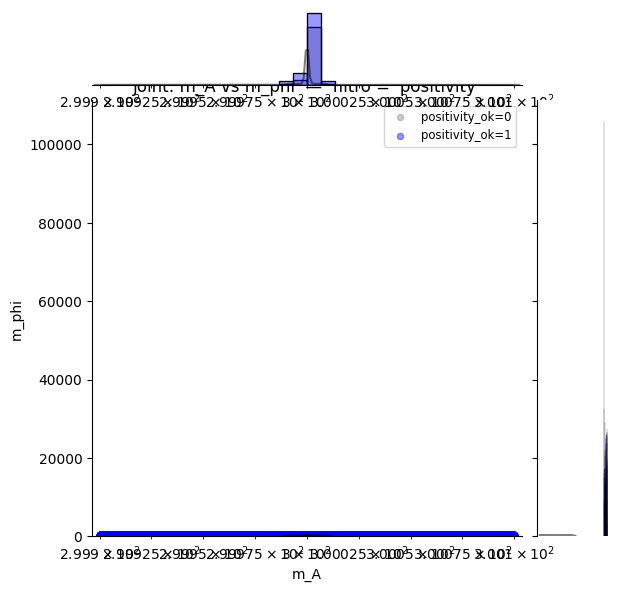

In [ ]:
# 1) Lista de parámetros a considerar:
params = ["m_A", "m_phi", "m12_2"]

# 2) Mapeo de columnas “tipo” a etiquetas cortas para el nombre de archivo:
mapeo_filtro = {
    "positivity_ok":    "positivity",
    "perturbativity_ok": "perturb",
    "unitarity_ok":      "unitary"
}

# 3) Carpeta donde se guardarán los joint plots:
output_dir = "img/joint"
os.makedirs(output_dir, exist_ok=True)

# 4) Para cada filtro (“positivity_ok”, “perturbativity_ok”, “unitarity_ok”),
#    generamos joint plots entre **todas** las combinaciones de dos parámetros.
for tipo in ["positivity_ok", "perturbativity_ok", "unitarity_ok"]:
    filtro = mapeo_filtro[tipo]
    
    # Can we just see this, its beautiful optimization for a repeated task 
    # ps: repeated task sucks so much
    for col_x, col_y in itertools.combinations(params, 2):
        # — Extraer las dos columnas que nos interesan 
        # ps: 
        serie_x = df[col_x]
        serie_y = df[col_y]
        
        # Si hay muy pocos datos válidos en cualquiera de las dos series, saltamos:
        if serie_x.dropna().shape[0] < 2 or serie_y.dropna().shape[0] < 2:
            print(f"Saltando joint plot para {tipo} en ({col_x}, {col_y}): datos insuficientes.")
            continue
        
        # — Creamos el JointGrid de seaborn —
        g = sns.JointGrid(data=df, x=col_x, y=col_y, height=6)
        
        # 4.1) Definimos los subconjuntos de clase 0 y clase 1 según el filtro actual:
        subset0 = df[df[tipo] == 0]
        subset1 = df[df[tipo] == 1]
        
        # 4.2) Marginales en el eje X (histograma de clase 0 y 1, escala log):
        sns.histplot(
            subset0[col_x].dropna(),
            bins=30,
            alpha=0.4,
            color="gray",
            log_scale=True,
            stat="count",
            ax=g.ax_marg_x
        )
        sns.histplot(
            subset1[col_x].dropna(),
            bins=30,
            alpha=0.4,
            color="blue",
            log_scale=True,
            stat="count",
            ax=g.ax_marg_x
        )
        # Overlay KDE marginal general en X (serie completa)
        sns.kdeplot(
            x=serie_x.dropna(),
            ax=g.ax_marg_x,
            color="black",
            alpha=0.5
        )
        
        # 4.3) Marginales en el eje Y (histograma horizontal de clase 0 y 1, escala log):
        sns.histplot(
            subset0[col_y].dropna(),
            bins=30,
            alpha=0.4,
            color="gray",
            log_scale=True,
            stat="count",
            orientation="horizontal",
            ax=g.ax_marg_y
        )
        sns.histplot(
            subset1[col_y].dropna(),
            bins=30,
            alpha=0.4,
            color="blue",
            log_scale=True,
            stat="count",
            orientation="horizontal",
            ax=g.ax_marg_y
        )
        # Overlay KDE marginal general en Y (serie completa)
        sns.kdeplot(
            y=serie_y.dropna(),
            ax=g.ax_marg_y,
            color="black",
            alpha=0.5
        )
        
        # 4.4) Plot bivariado en el panel central:
        #      - Scatter de clase 0 y clase 1
        g.ax_joint.scatter(
            subset0[col_x],
            subset0[col_y],
            s=20,
            color="gray",
            alpha=0.4,
            label=f"{tipo}=0"
        )
        g.ax_joint.scatter(
            subset1[col_x],
            subset1[col_y],
            s=20,
            color="blue",
            alpha=0.4,
            label=f"{tipo}=1"
        )
        #      - Contornos de KDE bivariado general (usando todos los puntos)
        sns.kdeplot(
            x=serie_x.dropna(),
            y=serie_y.dropna(),
            ax=g.ax_joint,
            levels=5,
            color="black",
            linewidths=1,
            alpha=0.5
        )
        
        # 4.5) Etiquetas y leyenda
        g.ax_joint.set_xlabel(col_x)
        g.ax_joint.set_ylabel(col_y)
        g.ax_joint.set_title(f"Joint: {col_x} vs {col_y}  —  filtro = '{filtro}'")
        g.ax_joint.legend(loc="upper right", fontsize="small")
        
        # 5) Guardar figura en PNG y luego opcionalmente mostrarla
        filename = f"v0601-{filtro}_{col_x}_{col_y}.png"
        fullpath = os.path.join(output_dir, filename)
        g.figure.savefig(fullpath, dpi=150)
        print(f"> Guardado joint plot: {fullpath}")
        
        # Mostrar la figura (opcional; coméntalo si no quieres ver cada plot en pantalla)
        plt.show()
        plt.close(g.figure)


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# 1) Load dataset
df = pd.read_parquet("data_train/dataset_full.parquet")


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

In [ ]:

# # 2) Derive perturbativity score
# lambda_cols = ["lambda1", "lambda2", "lambda3", "lambda4", "lambda5", "lambda6", "lambda7"]
# df["perturb_score"] = (df[lambda_cols]**2).sum(axis=1)

# # 3) Descriptive statistics by class
# desc_pos = df.groupby("perturbativity_ok")[lambda_cols + ["perturb_score"]].describe()
# print("Descriptive statistics for perturbativity_ok:")
# print(desc_pos)

# # 4) Histograms of perturb_score by class
# plt.figure()
# for cls in [0, 1]:
#     subset = df[df["perturbativity_ok"] == cls]
#     plt.hist(subset["perturb_score"], bins=50, alpha=0.5, label=f"class {cls}")
# plt.legend()
# plt.xlabel("Perturbativity score")
# plt.ylabel("Count")
# plt.title("Distribution of perturbativity score by class")

# # 5) Prepare features and labels
# X = df[["m_A", "m_phi", "m_12", "tan_beta", "sin_ba", "lambda_6", "lambda_7", "perturb_score"]]
# y = df["perturbativity_ok"]

# # 6) Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# # 7) Standardize
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # 8) Model 1: Logistic Regression
# logreg = LogisticRegression(max_iter=1000)
# logreg_scores = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring="accuracy")
# print(f"Logistic Regression CV accuracy: {logreg_scores.mean():.3f}")

# # 9) Model 2: Random Forest
# rf = RandomForestClassifier(n_estimators=100)
# rf_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="accuracy")
# print(f"Random Forest CV accuracy: {rf_scores.mean():.3f}")

# # 10) Hyperparameter tuning for RF
# param_grid = {
#     "n_estimators": [50, 100, 200],
#     "max_depth": [None, 5, 10],
#     "min_samples_split": [2, 5]
# }
# grid = GridSearchCV(rf, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
# grid.fit(X_train, y_train)
# print("Best RF params:", grid.best_params_)
# print(f"Tuned RF CV accuracy: {grid.best_score_:.3f}")


KeyError: "['lambda_1', 'lambda_2', 'lambda_3', 'lambda_4', 'lambda_5'] not in index"